**Coffee Roast Classification using DINOv3 and CNN**

Import libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from PIL import Image

Set random seed for reproducibility

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

Define dataset paths, model save path, hyperparameters, and device configuration

In [ ]:
TRAIN_DIR = "new_dataset/train"
VAL_DIR   = "new_dataset/val"
TEST_DIR  = "new_dataset/test"

MODEL_PATH = "dinov3_cnn.pth"

BATCH_SIZE = 16
NUM_CLASSES = 4
EPOCHS = 40
LR = 1e-3

PATIENCE = 10
MIN_DELTA = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)

Using: cuda


Define data augmentation for training and standard preprocessing for validation/testing

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(30),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.RandomErasing(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

Load datasets from directories and create data loaders for training, validation, and testing

In [ ]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=test_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Classes:", train_dataset.classes)

Classes: ['Dark', 'Green', 'Light', 'Medium']


Define a classifier using a frozen pretrained DINOv3 backbone with a custom CNN head

In [ ]:
class DinoClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = timm.create_model(
            "hf-hub:timm/convnext_base.dinov3_lvd1689m",
            pretrained=True,
            num_classes=0,
            global_pool=""
        )

        for p in self.backbone.parameters():
            p.requires_grad = False

        feature_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Conv2d(feature_dim, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone.forward_features(x)
        return self.head(x)

model = DinoClassifier(NUM_CLASSES).to(DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/350M [00:00<?, ?B/s]

Compute class weights to handle imbalance
Define loss function, optimizer, and learning rate scheduler

In [ ]:
labels = train_dataset.targets

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adamax(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.2, patience=3
)

Train the model with early stopping

In [ ]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
counter = 0

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0
    correct, total = 0, 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        total += y.size(0)
        correct += (preds == y).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * correct / total

    model.eval()
    val_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            total += y.size(0)
            correct += (preds == y).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: "
          f"Train Loss {train_loss:.4f}, Acc {train_acc:.2f}% | "
          f"Val Loss {val_loss:.4f}, Acc {val_acc:.2f}%")

    scheduler.step(val_loss)

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping")
            break

Epoch 1: Train Loss 0.3901, Acc 86.18% | Val Loss 0.1678, Acc 95.18%
Epoch 2: Train Loss 0.2080, Acc 93.10% | Val Loss 0.2866, Acc 88.65%
Epoch 3: Train Loss 0.1647, Acc 94.65% | Val Loss 0.2935, Acc 87.38%
Epoch 4: Train Loss 0.1379, Acc 95.60% | Val Loss 0.1548, Acc 93.19%
Epoch 5: Train Loss 0.1332, Acc 95.29% | Val Loss 0.2613, Acc 89.93%
Epoch 6: Train Loss 0.1175, Acc 95.90% | Val Loss 0.1456, Acc 94.75%
Epoch 7: Train Loss 0.1139, Acc 95.87% | Val Loss 0.3841, Acc 85.67%
Epoch 8: Train Loss 0.1145, Acc 96.08% | Val Loss 0.1207, Acc 96.45%
Epoch 9: Train Loss 0.1205, Acc 95.72% | Val Loss 0.1280, Acc 96.31%
Epoch 10: Train Loss 0.0990, Acc 96.51% | Val Loss 0.0211, Acc 99.57%
Epoch 11: Train Loss 0.0926, Acc 96.87% | Val Loss 0.1094, Acc 95.32%
Epoch 12: Train Loss 0.0892, Acc 96.87% | Val Loss 0.0678, Acc 97.73%
Epoch 13: Train Loss 0.0800, Acc 97.11% | Val Loss 0.1578, Acc 93.19%
Epoch 14: Train Loss 0.0776, Acc 97.11% | Val Loss 0.0328, Acc 99.15%
Epoch 15: Train Loss 0.0684, 

Plot training and validation loss and accuracy

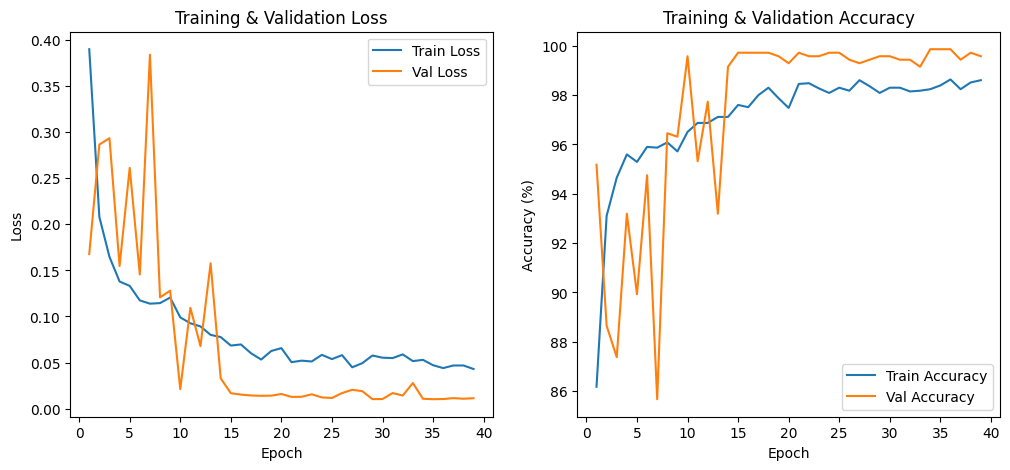

In [ ]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training & Validation Accuracy")
plt.legend()

plt.show()

Test the best saved model on the test set

In [ ]:
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

correct, total = 0, 0

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        total += y.size(0)
        correct += (preds == y).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(f"Test Accuracy: {100*correct/total:.2f}%")

Test Accuracy: 100.00%


Generate a classification report including precision, recall, and F1-score

In [ ]:
class_names = test_dataset.classes

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        Dark     1.0000    1.0000    1.0000       176
       Green     1.0000    1.0000    1.0000       177
       Light     1.0000    1.0000    1.0000       179
      Medium     1.0000    1.0000    1.0000       177

    accuracy                         1.0000       709
   macro avg     1.0000    1.0000    1.0000       709
weighted avg     1.0000    1.0000    1.0000       709



Plot confusion matrix

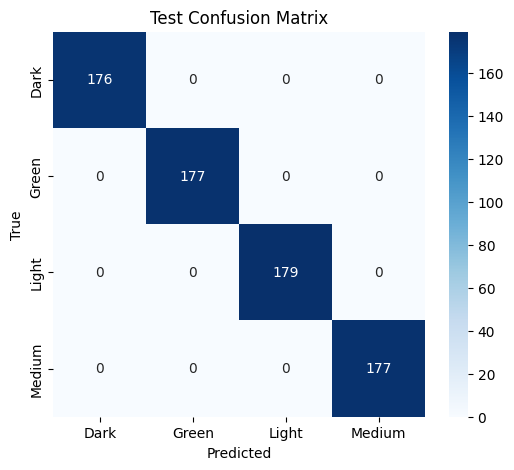

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

class_names = test_dataset.classes

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="g",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

Test inference using the trained model on a single image

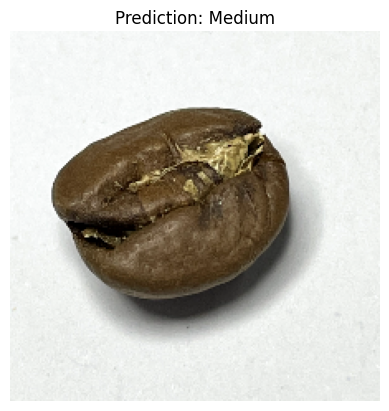

In [ ]:
image_path = "new_dataset/test/Medium/Medium_0.png"

image = Image.open(image_path).convert("RGB")
x = test_transform(image).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred = torch.argmax(model(x), dim=1).item()

class_names = train_dataset.classes

plt.imshow(image)
plt.title(f"Prediction: {class_names[pred]}")
plt.axis("off")
plt.show()